# ECG200: detecting ischemic heartbeats

ECG200 is a classic dataset of 200 single heartbeats recorded
from one ECG lead. Each beat is 96 samples long. Of the 200 beats, 133 are
normal and 67 come from patients with myocardial infarction (a heart
attack). We want a method that can tell the two apart without seeing the
labels in advance.

A normal heartbeat differs from an ischemic
one in two essentially independent ways:

Shape. The waveform itself is distorted, the T-wave can flip, the
  ST-segment can shift, the Q-wave can deepen.

Amplitude. Ischemic beats often have a smaller peak-to-peak swing
  than normal ones.

We turn each view into a distance between heartbeats:

`filt_shape` compares two beats after z-normalising them (subtracting the
  mean, dividing by the std).

`filt_amp` is just the difference of peak-to-peak values. It sees only
  amplitude and ignores the shape entirely.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from tslearn.datasets import UCR_UEA_datasets
import hdbscan

from mpc.filtration_builder import assemble_filtration
from mpc.pipeline import run_bifiltration_edges

## Data

N=200, train=140, test=60


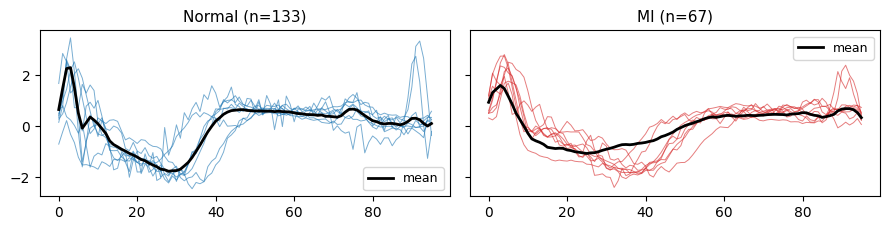

In [2]:
from sklearn.model_selection import train_test_split

X_tr, y_tr, X_te, y_te = UCR_UEA_datasets().load_dataset('ECG200')
X = np.vstack([X_tr.squeeze(-1), X_te.squeeze(-1)])
y_raw = np.concatenate([y_tr, y_te])
y_true = (y_raw == -1).astype(int)
sub = np.where(y_true == 1, "MI", "Normal")
N, L = X.shape

all_idx = np.arange(N)
train_idx, test_idx = train_test_split(all_idx, test_size=0.3,
                                       stratify=y_true, random_state=42)
train_idx.sort(); test_idx.sort()
y_train = y_true[train_idx]; y_test = y_true[test_idx]
print(f"N={N}, train={len(train_idx)}, test={len(test_idx)}")

fig, axes = plt.subplots(1, 2, figsize=(9, 2.4), sharey=True)
for ax, cls, color in zip(axes, ("Normal", "MI"), ("C0", "C3")):
    for i in np.where(sub == cls)[0][:8]:
        ax.plot(X[i], color=color, lw=0.7, alpha=0.6)
    ax.plot(X[sub == cls].mean(0), color="k", lw=2.0, label="mean")
    ax.set_title(f"{cls} (n={(sub==cls).sum()})", fontsize=11)
    ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Filtrations

There are six candidate axes:

`shape` -- z-normalized waveform L2 (location & scale removed → morphology).

`amp`   -- peak-to-peak amplitude (1-D scalar).

`raw`   -- raw waveform L2 (mixes shape and amplitude).

`deriv` -- first-difference L2 (smoothness / sharpness).

`spec`  -- FFT magnitude L2 (spectral content).

`peakloc` -- |argmax_i - argmax_j| (R-peak position).

The main pair is `shape x amp`.

In [3]:
Xz = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-9)
amp = X.max(1) - X.min(1)
dX = np.diff(X, axis=1)
spec = np.abs(np.fft.rfft(Xz))
peak_loc = np.argmax(X, axis=1).astype(float)

D_axes = {
    "shape": cdist(Xz, Xz),
    "amp": np.abs(amp[:, None] - amp[None, :]),
    "raw": cdist(X, X),
    "deriv": cdist(dX, dX),
    "spec": cdist(spec, spec),
    "peakloc": np.abs(peak_loc[:, None] - peak_loc[None, :]),
}
iu, ju = np.triu_indices(N, k=1)
edges = list(zip(iu.tolist(), ju.tolist()))
F_axes = {k: assemble_filtration(N, edges, v[iu, ju]) for k, v in D_axes.items()}

filt_shape, filt_amp = F_axes["shape"], F_axes["amp"]

## Train-tuned, test-evaluated

In [4]:
def best_anom_cluster_on(labels, idx_subset, y_subset):
    best_mask, best_f1 = np.zeros_like(labels, dtype=int), -1.0
    for c in np.unique(labels[labels >= 0]):
        cand = (labels == c).astype(int)
        f = f1_score(y_subset, cand[idx_subset], zero_division=0)
        if f > best_f1:
            best_f1, best_mask = f, cand
    return best_mask, best_f1

def tune_and_eval(name, configs):
    best_f1, best_pred, best_label = -1.0, None, None
    for label, labels in configs:
        pred, f1 = best_anom_cluster_on(np.asarray(labels), train_idx, y_train)
        if f1 > best_f1:
            best_f1, best_pred, best_label = f1, pred, label
    p = precision_score(y_test, best_pred[test_idx], zero_division=0)
    r = recall_score(y_test, best_pred[test_idx], zero_division=0)
    f = f1_score(y_test, best_pred[test_idx], zero_division=0)
    return {"method": name, "best_config": best_label, "train_F1": best_f1,
            "test_P": p, "test_R": r, "test_F1": f, "pred": best_pred}

def bif_configs(methods):
    cfgs = []
    for slope in [0.0625, 0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]:
        for k in [2, 3, 4, 5, 6]:
            for meth in methods:
                if meth == "simplify":
                    for ms in [2, 3, 5, 8, 12, 20]:
                        r = run_bifiltration_edges(N, filt_shape, filt_amp, method=meth,
                                                   n_clusters=k, slope=slope, min_size=ms)
                        cfgs.append((f"{meth} slope={slope} k={k} ms={ms}", r.labels_combined))
                else:
                    r = run_bifiltration_edges(N, filt_shape, filt_amp, method=meth,
                                               n_clusters=k, slope=slope)
                    cfgs.append((f"{meth} slope={slope} k={k}", r.labels_combined))
    return cfgs

feat = StandardScaler().fit_transform(np.column_stack([
    np.linalg.norm(Xz - Xz.mean(0), axis=1), amp]))

km_cfgs = [(f"raw{L} k={k}",
            KMeans(n_clusters=k, n_init=50, max_iter=500,
                   random_state=42).fit_predict(Xz))
           for k in [2, 3, 4, 5]]
ward_cfgs = [(f"{lk} k={k}", AgglomerativeClustering(n_clusters=k, linkage=lk).fit_predict(feat))
             for lk in ("ward", "average", "complete") for k in [2, 3, 4, 5]]
gmm_cfgs = [(f"{cov} k={k}", GaussianMixture(n_components=k, covariance_type=cov, n_init=20,
                                             max_iter=500, reg_covar=1e-4,
                                             random_state=42).fit_predict(feat))
            for cov in ("full", "tied", "diag") for k in [2, 3, 4, 5]]
hdb_cfgs = [(f"mcs={mcs}", hdbscan.HDBSCAN(min_cluster_size=mcs).fit_predict(feat))
            for mcs in [5, 10, 15, 20, 30]]

results = [
    tune_and_eval("Bifiltration (persist)",  bif_configs(("persistence",))),
    tune_and_eval("Bifiltration (simplify)", bif_configs(("simplify",))),
    tune_and_eval("KMeans", km_cfgs),
    tune_and_eval("Ward", ward_cfgs),
    tune_and_eval("GMM", gmm_cfgs),
    tune_and_eval("HDBSCAN", hdb_cfgs),
]
df = pd.DataFrame([{k: v for k, v in r.items() if k != "pred"} for r in results])
df.sort_values("test_F1", ascending=False).reset_index(drop=True).round(3)

,method,best_config,train_F1,test_P,test_R,test_F1
0,Bifiltration (persist),persistence slope=0.5 k=3,0.804,0.760,0.95,0.844
1,Bifiltration (simplify),simplify slope=1.0 k=2 ms=20,0.776,0.655,0.95,0.776
2,GMM,full k=2,0.737,0.630,0.85,0.723
3,Ward,complete k=2,0.733,0.579,0.55,0.564
4,KMeans,raw96 k=4,0.595,0.625,0.50,0.556
5,HDBSCAN,mcs=15,0.543,1.000,0.30,0.462


## Alternative filtration pairs

In [5]:
def tune_pair(f1, f2):
    cfgs = []
    for slope in [0.0625, 0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]:
        for k in [2, 3, 4, 5, 6]:
            for meth in ("persistence", "simplify"):
                kw = dict(method=meth, n_clusters=k, slope=slope)
                if meth == "simplify":
                    kw["min_size"] = 5
                r = run_bifiltration_edges(N, f1, f2, **kw)
                cfgs.append((f"{meth} slope={slope} k={k}", r.labels_combined))
    return tune_and_eval("Bif", cfgs)

pairs_to_test = [("shape", "amp"), ("spec", "peakloc"), ("raw", "shape"),
                 ("shape", "deriv"), ("amp", "deriv"), ("raw", "amp")]
pair_rows = []
for a, b in pairs_to_test:
    res = tune_pair(F_axes[a], F_axes[b])
    pair_rows.append({"pair": f"{a} x {b}", "config": res["best_config"],
                      "train_F1": res["train_F1"], "test_P": res["test_P"],
                      "test_R": res["test_R"], "test_F1": res["test_F1"]})
pd.DataFrame(pair_rows).sort_values("test_F1", ascending=False).round(3)

,pair,config,train_F1,test_P,test_R,test_F1
1,spec x peakloc,persistence slope=4.0 k=3,0.789,0.741,1.00,0.851
0,shape x amp,persistence slope=0.5 k=3,0.804,0.760,0.95,0.844
5,raw x amp,persistence slope=0.5 k=3,0.804,0.760,0.95,0.844
2,raw x shape,persistence slope=0.0625 k=2,0.776,0.655,0.95,0.776
3,shape x deriv,persistence slope=4.0 k=2,0.776,0.655,0.95,0.776
4,amp x deriv,simplify slope=0.0625 k=2,0.716,0.562,0.45,0.500


## Predictions in the (shape, amp) plane

Each point is one heartbeat, projected to the two scalar features underlying
the filtrations:

x = `||z(x) - mean_z||_2`, shape distance to the mean z-normalized beat

y = `peak2peak(x)`, amplitude (the scalar defining `filt_amp`).

Color = predicted class (red = pred MI, gray = pred normal). Only test
points are shown.

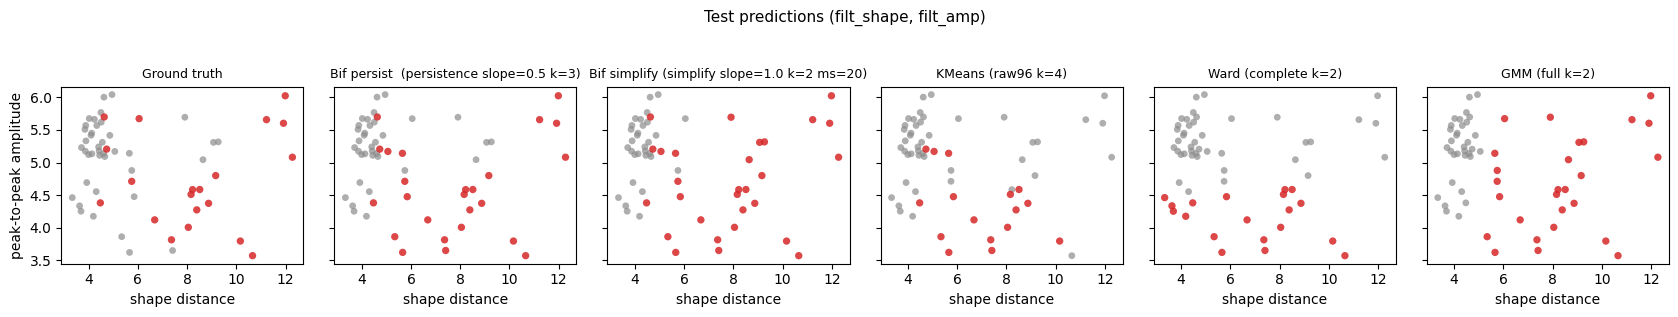

In [6]:
res_by_name = {r["method"]: r for r in results}
shape_x = np.linalg.norm(Xz - Xz.mean(0), axis=1)
amp_y   = amp

methods_to_show = [
    ("Ground truth", y_true),
    (f"Bif persist  ({res_by_name['Bifiltration (persist)']['best_config']})",
     res_by_name["Bifiltration (persist)"]["pred"]),
    (f"Bif simplify ({res_by_name['Bifiltration (simplify)']['best_config']})",
     res_by_name["Bifiltration (simplify)"]["pred"]),
    (f"KMeans ({res_by_name['KMeans']['best_config']})", res_by_name["KMeans"]["pred"]),
    (f"Ward ({res_by_name['Ward']['best_config']})", res_by_name["Ward"]["pred"]),
    (f"GMM ({res_by_name['GMM']['best_config']})", res_by_name["GMM"]["pred"]),
]

fig, axes = plt.subplots(1, len(methods_to_show), figsize=(17, 3.0),
                         sharex=True, sharey=True)
for ax, (name, pred) in zip(axes, methods_to_show):
    pred = np.asarray(pred).astype(int)
    xt, yt, pt = shape_x[test_idx], amp_y[test_idx], pred[test_idx]
    ax.scatter(xt[pt == 0], yt[pt == 0], s=24, c="0.55", alpha=0.7,
               edgecolors="none", label="pred normal")
    ax.scatter(xt[pt == 1], yt[pt == 1], s=28, c="C3", alpha=0.85,
               edgecolors="none", label="pred MI")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("shape distance")
axes[0].set_ylabel("peak-to-peak amplitude")
fig.suptitle("Test predictions (filt_shape, filt_amp)", y=1.04, fontsize=11)
fig.tight_layout()
plt.show()

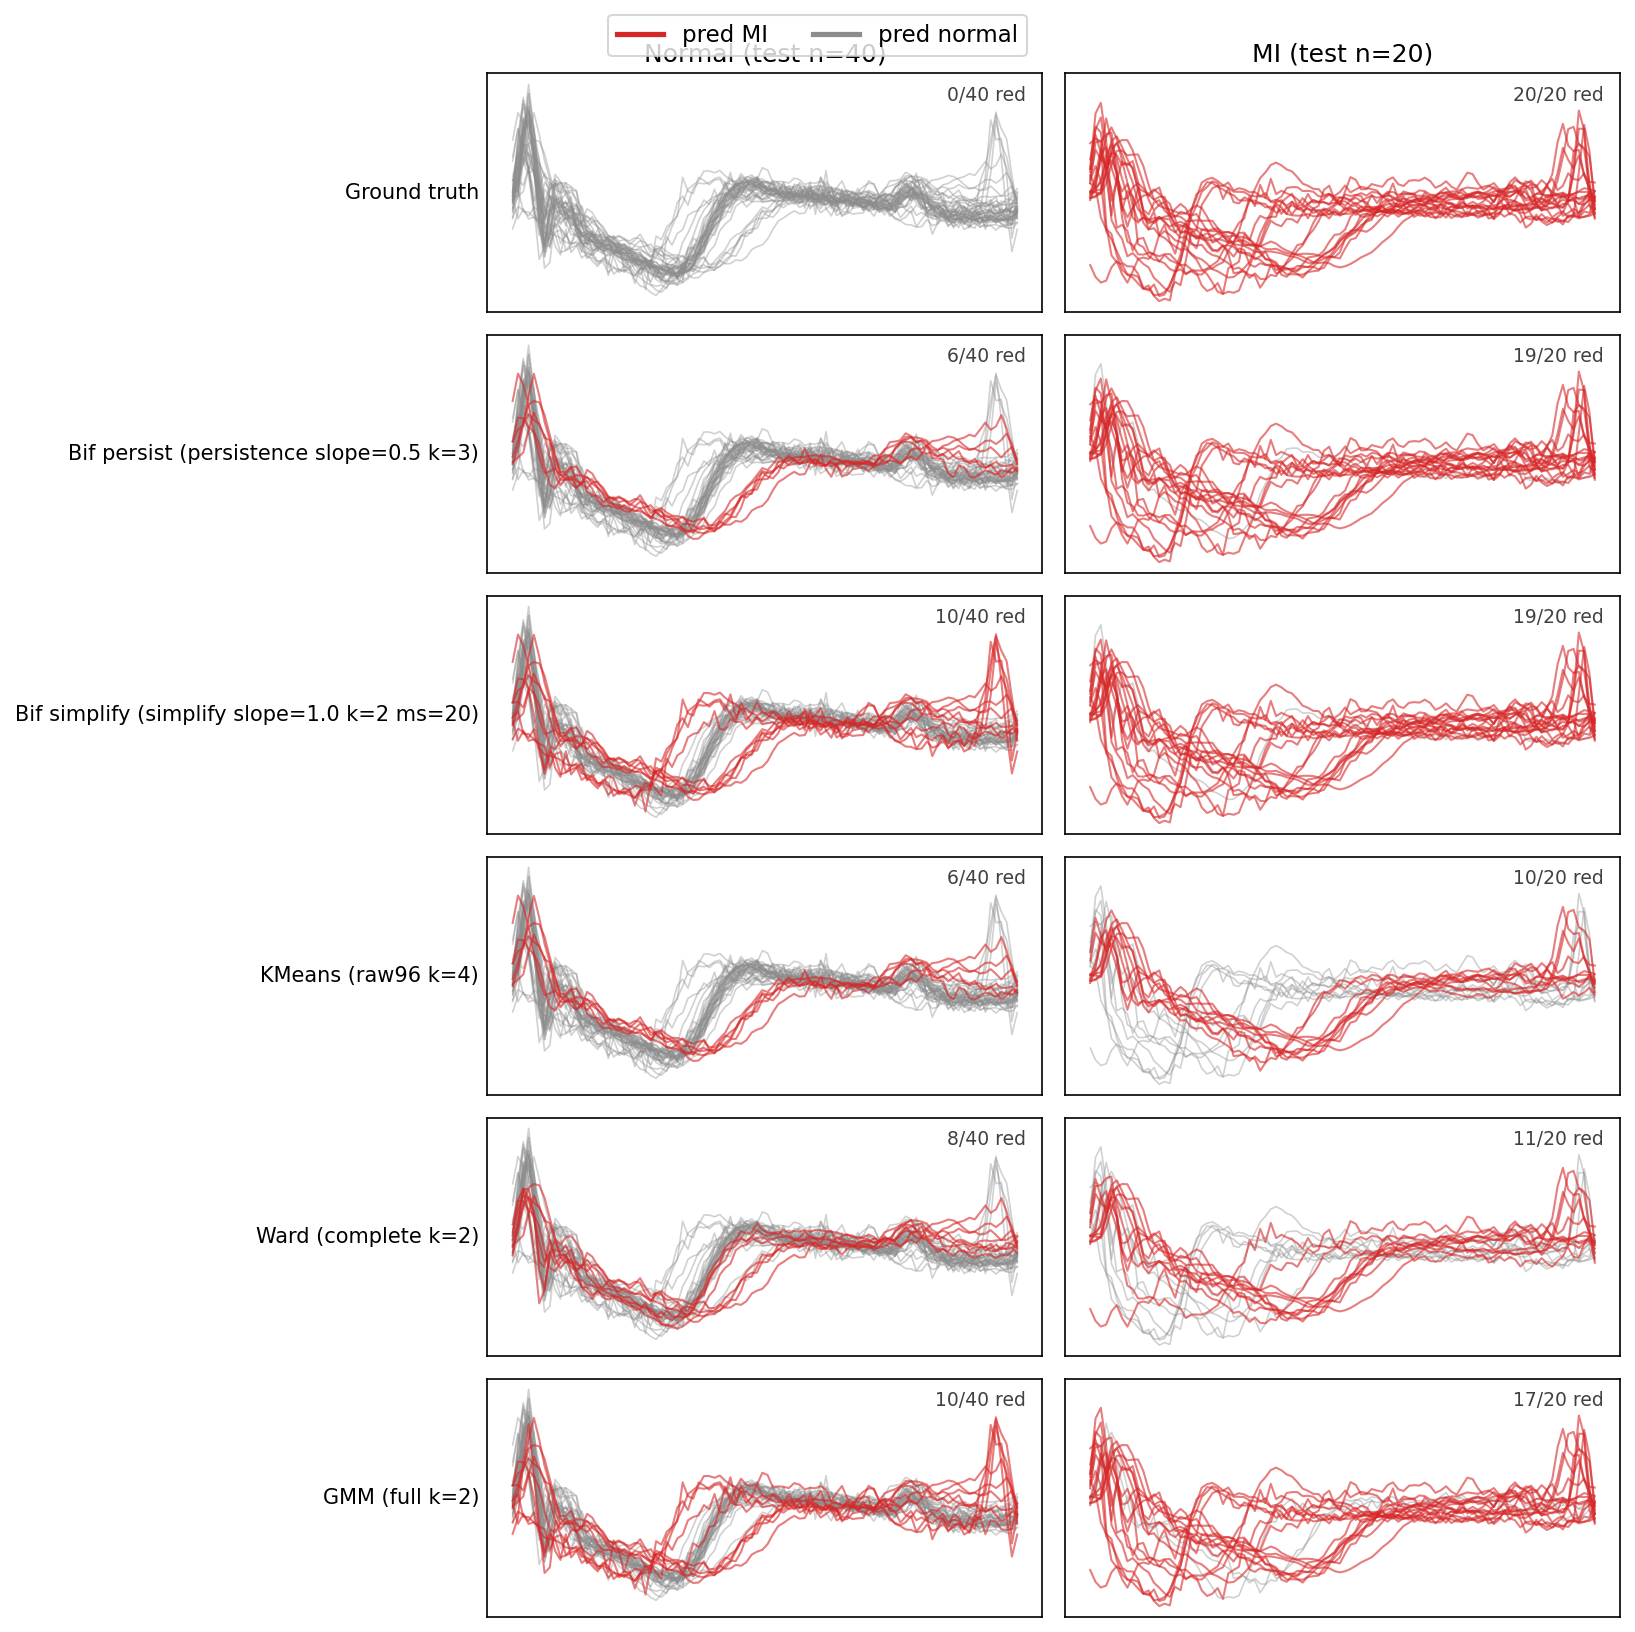

In [7]:
CLS_ORDER = ("Normal", "MI")
PRED_COLORS = {0: "0.55", 1: "C3"}
res_by_name = {r["method"]: r for r in results}

rows_to_show = [
    ("Ground truth", y_true),
    (f"Bif persist ({res_by_name['Bifiltration (persist)']['best_config']})",
     res_by_name["Bifiltration (persist)"]["pred"]),
    (f"Bif simplify ({res_by_name['Bifiltration (simplify)']['best_config']})",
     res_by_name["Bifiltration (simplify)"]["pred"]),
    (f"KMeans ({res_by_name['KMeans']['best_config']})", res_by_name["KMeans"]["pred"]),
    (f"Ward ({res_by_name['Ward']['best_config']})", res_by_name["Ward"]["pred"]),
    (f"GMM ({res_by_name['GMM']['best_config']})", res_by_name["GMM"]["pred"]),
]

fig, axes = plt.subplots(len(rows_to_show), 2, figsize=(11, 1.8 * len(rows_to_show)),
                         sharex=True, sharey=True, dpi=150)
for row, (name, pred) in enumerate(rows_to_show):
    pred = np.asarray(pred).astype(int)
    for col, c in enumerate(CLS_ORDER):
        ax = axes[row, col]
        idxs = test_idx[sub[test_idx] == c]
        for i in idxs[pred[idxs] == 0]:
            ax.plot(X[i], color=PRED_COLORS[0], lw=0.8, alpha=0.4)
        for i in idxs[pred[idxs] == 1]:
            ax.plot(X[i], color=PRED_COLORS[1], lw=1.0, alpha=0.6)
        n_pos = int(pred[idxs].sum())
        ax.set_xticks([]); ax.set_yticks([])
        ax.text(0.97, 0.95, f"{n_pos}/{len(idxs)} red", transform=ax.transAxes,
                ha="right", va="top", fontsize=9, color="0.25")
        if row == 0: ax.set_title(f"{c} (test n={len(idxs)})", fontsize=12)
        if col == 0: ax.set_ylabel(name, fontsize=10, rotation=0, ha="right", va="center")

handles = [plt.Line2D([0], [0], color=PRED_COLORS[1], lw=2.5, label="pred MI"),
           plt.Line2D([0], [0], color=PRED_COLORS[0], lw=2.5, label="pred normal")]
fig.legend(handles=handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.01), fontsize=11)
fig.tight_layout()
plt.show()